In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:

# Localizar os 47 voos
from pathlib import Path

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

flights = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("_")])

print("Total de voos encontrados:", len(flights))

for f in flights:
    print(f.name)

Total de voos encontrados: 47
carbonZ_2018-07-18-12-10-11_no_ground_truth
carbonZ_2018-07-18-15-53-31_1_engine_failure
carbonZ_2018-07-18-15-53-31_2_engine_failure
carbonZ_2018-07-18-16-22-01_engine_failure_with_emr_traj
carbonZ_2018-07-18-16-37-39_1_no_failure
carbonZ_2018-07-18-16-37-39_2_engine_failure_with_emr_traj
carbonZ_2018-07-30-16-29-45_engine_failure_with_emr_traj
carbonZ_2018-07-30-16-39-00_1_engine_failure
carbonZ_2018-07-30-16-39-00_2_engine_failure
carbonZ_2018-07-30-16-39-00_3_no_failure
carbonZ_2018-07-30-17-10-45_engine_failure_with_emr_traj
carbonZ_2018-07-30-17-20-01_engine_failure_with_emr_traj
carbonZ_2018-07-30-17-36-35_engine_failure_with_emr_traj
carbonZ_2018-07-30-17-46-31_engine_failure_with_emr_traj
carbonZ_2018-09-11-11-56-30_engine_failure
carbonZ_2018-09-11-14-16-55_no_failure
carbonZ_2018-09-11-14-22-07_1_engine_failure
carbonZ_2018-09-11-14-22-07_2_engine_failure
carbonZ_2018-09-11-14-41-38_no_failure
carbonZ_2018-09-11-14-41-51_elevator_failure
carbonZ

In [4]:
# Script para conferir se cada voo tem bateria e odometria

from pathlib import Path
import pandas as pd

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")
flights = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("_")])

rows = []

for flight in flights:
    battery_files = list(flight.glob("*mavros-battery*.csv"))
    odom_files = list(flight.glob("*mavros-local_position-odom*.csv"))

    rows.append({
        "flight": flight.name,
        "n_battery_files": len(battery_files),
        "n_odom_files": len(odom_files),
        "battery_ok": len(battery_files) > 0,
        "odom_ok": len(odom_files) > 0
    })

check_df = pd.DataFrame(rows)

print(check_df.head())
print("\nResumo:")
print(check_df[["battery_ok", "odom_ok"]].value_counts())

                                              flight  n_battery_files  \
0        carbonZ_2018-07-18-12-10-11_no_ground_truth                1   
1       carbonZ_2018-07-18-15-53-31_1_engine_failure                1   
2       carbonZ_2018-07-18-15-53-31_2_engine_failure                1   
3  carbonZ_2018-07-18-16-22-01_engine_failure_wit...                1   
4           carbonZ_2018-07-18-16-37-39_1_no_failure                1   

   n_odom_files  battery_ok  odom_ok  
0             1        True     True  
1             1        True     True  
2             1        True     True  
3             1        True     True  
4             1        True     True  

Resumo:
battery_ok  odom_ok
True        True       47
Name: count, dtype: int64


In [5]:
# Cria um arquivo consolidado para cada voo

from pathlib import Path
import numpy as np
import pandas as pd

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")
flights = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("_")])

def make_time_s(df, time_col="pcttime"):
    t = pd.to_numeric(df[time_col], errors="coerce")

    med = np.nanmedian(t.to_numpy()) if np.isfinite(t.to_numpy()).any() else np.nan

    if np.isfinite(med) and med > 1e12:
        t = t / 1e9
    elif np.isfinite(med) and med > 1e9:
        t = t / 1e3
    else:
        t = t.astype("float64")

    t0 = np.nanmin(t.to_numpy()) if np.isfinite(t.to_numpy()).any() else 0.0
    return (t - t0).astype("float64")

def build_consolidated(flight_dir):
    battery_files = list(flight_dir.glob("*mavros-battery*.csv"))
    odom_files = list(flight_dir.glob("*mavros-local_position-odom*.csv"))

    if len(battery_files) == 0:
        return {"flight": flight_dir.name, "status": "battery ausente"}

    if len(odom_files) == 0:
        return {"flight": flight_dir.name, "status": "odom ausente"}

    battery = pd.read_csv(battery_files[0], low_memory=False)
    odom = pd.read_csv(odom_files[0], low_memory=False)

    battery["time_s"] = make_time_s(battery, "pcttime")
    odom["time_s"] = make_time_s(odom, "pcttime")

    battery = battery.drop_duplicates(subset=["time_s"]).sort_values("time_s")
    odom = odom.drop_duplicates(subset=["time_s"]).sort_values("time_s")

    battery = battery[[
        "time_s",
        "field_voltage",
        "field_current",
        "field_percentage"
    ]]

    odom = odom[[
        "time_s",
        "field_pose_pose_position_x",
        "field_pose_pose_position_y",
        "field_pose_pose_position_z",
        "field_twist_twist_linear_x",
        "field_twist_twist_linear_y",
        "field_twist_twist_linear_z"
    ]]

    battery = battery.rename(columns={
        "field_voltage": "voltage_v",
        "field_current": "current_a",
        "field_percentage": "battery_pct"
    })

    odom = odom.rename(columns={
        "field_pose_pose_position_x": "x_m",
        "field_pose_pose_position_y": "y_m",
        "field_pose_pose_position_z": "z_m",
        "field_twist_twist_linear_x": "vx_mps",
        "field_twist_twist_linear_y": "vy_mps",
        "field_twist_twist_linear_z": "vz_mps"
    })

    consolidated = pd.merge_asof(
        odom.sort_values("time_s"),
        battery.sort_values("time_s"),
        on="time_s",
        direction="nearest",
        tolerance=0.25
    )

    consolidated["speed_mps"] = np.sqrt(
        consolidated["vx_mps"]**2 +
        consolidated["vy_mps"]**2 +
        consolidated["vz_mps"]**2
    )

    consolidated["power_w"] = consolidated["voltage_v"] * consolidated["current_a"]

    out_path = flight_dir / "flight_consolidated.csv"
    consolidated.to_csv(out_path, index=False)

    return {
        "flight": flight_dir.name,
        "status": "ok",
        "rows": consolidated.shape[0],
        "saved_to": str(out_path)
    }

results = []

for i, flight in enumerate(flights, start=1):
    result = build_consolidated(flight)
    results.append(result)

    if i % 10 == 0 or i == len(flights):
        print(f"{i}/{len(flights)} voos processados")

results_df = pd.DataFrame(results)

print("\nResumo:")
print(results_df.head())

out_file = DATA_ROOT / "resumo_consolidacao.csv"
results_df.to_csv(out_file, index=False)

print("\nArquivo salvo em:")
print(out_file)

10/47 voos processados
20/47 voos processados
30/47 voos processados
40/47 voos processados
47/47 voos processados

Resumo:
                                              flight status  rows  \
0        carbonZ_2018-07-18-12-10-11_no_ground_truth     ok   838   
1       carbonZ_2018-07-18-15-53-31_1_engine_failure     ok   544   
2       carbonZ_2018-07-18-15-53-31_2_engine_failure     ok   366   
3  carbonZ_2018-07-18-16-22-01_engine_failure_wit...     ok   545   
4           carbonZ_2018-07-18-16-37-39_1_no_failure     ok   126   

                                            saved_to  
0  /content/gdrive/MyDrive/datasets/ALFA/processe...  
1  /content/gdrive/MyDrive/datasets/ALFA/processe...  
2  /content/gdrive/MyDrive/datasets/ALFA/processe...  
3  /content/gdrive/MyDrive/datasets/ALFA/processe...  
4  /content/gdrive/MyDrive/datasets/ALFA/processe...  

Arquivo salvo em:
/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado/resumo_consolidacao.csv


In [6]:
# Teste de um voo consolidado
import pandas as pd
from pathlib import Path

flight_test = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado") / flights[0].name / "flight_consolidated.csv"

df = pd.read_csv(flight_test)

print(df.head())
print(df.columns)
print(df.shape)

     time_s        x_m        y_m        z_m     vx_mps    vy_mps    vz_mps  \
0  0.000000  62.352993  65.115738  82.393654  20.290154  1.685620  1.297396   
1  0.236231  57.676174  65.016670  83.418953  19.946733  1.663622  1.314114   
2  0.460446  53.039860  64.923584  84.491455  19.530307  1.535776  0.921271   
3  0.713010  48.516273  64.879158  85.525459  19.027162  1.193508  0.355700   
4  0.970306  43.789360  64.937431  86.418839  18.400598  1.229144 -0.186875   

   voltage_v  current_a  battery_pct  speed_mps  power_w  
0        0.0       0.01        -0.01  20.401346      0.0  
1        0.0       0.01        -0.01  20.059080      0.0  
2        0.0       0.01        -0.01  19.612248      0.0  
3        0.0       0.01        -0.01  19.067876      0.0  
4        0.0       0.01        -0.01  18.442552      0.0  
Index(['time_s', 'x_m', 'y_m', 'z_m', 'vx_mps', 'vy_mps', 'vz_mps',
       'voltage_v', 'current_a', 'battery_pct', 'speed_mps', 'power_w'],
      dtype='object')
(838, 12

In [7]:
# Verificar se os dados de bateria são válidos

import pandas as pd
from pathlib import Path
import numpy as np

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

flights = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("_")])

rows = []

for flight in flights:
    csv_path = flight / "flight_consolidated.csv"

    if not csv_path.exists():
        rows.append({
            "flight": flight.name,
            "battery_valid": False,
            "reason": "sem_consolidado"
        })
        continue

    df = pd.read_csv(csv_path)

    if "voltage_v" not in df.columns or "current_a" not in df.columns:
        rows.append({
            "flight": flight.name,
            "battery_valid": False,
            "reason": "colunas_ausentes"
        })
        continue

    voltage_mean = df["voltage_v"].mean()
    current_mean = df["current_a"].mean()

    # critérios simples de validade
    battery_valid = (
        voltage_mean > 5.0 and
        current_mean > 0.1
    )

    rows.append({
        "flight": flight.name,
        "battery_valid": battery_valid,
        "voltage_mean": voltage_mean,
        "current_mean": current_mean
    })

check_battery = pd.DataFrame(rows)

print(check_battery.head())

print("\nResumo:")
print(check_battery["battery_valid"].value_counts())

                                              flight  battery_valid  \
0        carbonZ_2018-07-18-12-10-11_no_ground_truth          False   
1       carbonZ_2018-07-18-15-53-31_1_engine_failure          False   
2       carbonZ_2018-07-18-15-53-31_2_engine_failure          False   
3  carbonZ_2018-07-18-16-22-01_engine_failure_wit...          False   
4           carbonZ_2018-07-18-16-37-39_1_no_failure          False   

   voltage_mean  current_mean  
0           0.0          0.01  
1           0.0          0.01  
2           0.0          0.01  
3           0.0          0.01  
4           0.0          0.01  

Resumo:
battery_valid
False    47
Name: count, dtype: int64


In [8]:
# Calcular métricas dinâmicas para todos os voos

from pathlib import Path
import numpy as np
import pandas as pd

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

flights = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("_")])

print("Total de voos encontrados:", len(flights))


def classify_flight(name):
    if "engine_failure" in name:
        return "engine_failure"
    elif "no_failure" in name:
        return "no_failure"
    elif "no_ground_truth" in name:
        return "no_ground_truth"
    else:
        return "other"


def compute_dynamic_metrics(flight_dir):
    csv_path = flight_dir / "flight_consolidated.csv"

    if not csv_path.exists():
        return {
            "flight": flight_dir.name,
            "flight_type": classify_flight(flight_dir.name),
            "status": "sem_consolidado"
        }

    df = pd.read_csv(csv_path)

    needed = ["time_s", "vx_mps", "vy_mps", "vz_mps"]

    for col in needed:
        if col not in df.columns:
            return {
                "flight": flight_dir.name,
                "flight_type": classify_flight(flight_dir.name),
                "status": f"coluna_ausente_{col}"
            }

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=needed).copy()

    if len(df) < 10:
        return {
            "flight": flight_dir.name,
            "flight_type": classify_flight(flight_dir.name),
            "status": "poucos_dados"
        }

    t = df["time_s"].to_numpy(dtype=float)
    vx = df["vx_mps"].to_numpy(dtype=float)
    vy = df["vy_mps"].to_numpy(dtype=float)
    vz = df["vz_mps"].to_numpy(dtype=float)

    eps = 1e-9

    dt = np.gradient(t)
    dt[dt == 0] = eps

    ax = np.gradient(vx) / (dt + eps)
    ay = np.gradient(vy) / (dt + eps)
    az = np.gradient(vz) / (dt + eps)

    accel = np.sqrt(ax**2 + ay**2 + az**2)

    jx = np.gradient(ax) / (dt + eps)
    jy = np.gradient(ay) / (dt + eps)
    jz = np.gradient(az) / (dt + eps)

    jerk = np.sqrt(jx**2 + jy**2 + jz**2)

    return {
        "flight": flight_dir.name,
        "flight_type": classify_flight(flight_dir.name),
        "status": "ok",
        "n_points": len(df),
        "accel_mean": float(np.mean(accel)),
        "accel_std": float(np.std(accel)),
        "jerk_mean": float(np.mean(jerk)),
        "jerk_std": float(np.std(jerk)),
        "accel_max": float(np.max(accel)),
        "jerk_max": float(np.max(jerk))
    }


rows = []

for i, flight in enumerate(flights, start=1):
    result = compute_dynamic_metrics(flight)
    rows.append(result)

    if i % 10 == 0 or i == len(flights):
        print(f"{i}/{len(flights)} voos processados")

df_metrics = pd.DataFrame(rows)

out_file = DATA_ROOT / "motor_dynamic_metrics.csv"
df_metrics.to_csv(out_file, index=False)

print("\nArquivo salvo em:")
print(out_file)

print("\nPrimeiras linhas:")
print(df_metrics.head())

Total de voos encontrados: 47
10/47 voos processados
20/47 voos processados
30/47 voos processados
40/47 voos processados
47/47 voos processados

Arquivo salvo em:
/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado/motor_dynamic_metrics.csv

Primeiras linhas:
                                              flight      flight_type status  \
0        carbonZ_2018-07-18-12-10-11_no_ground_truth  no_ground_truth     ok   
1       carbonZ_2018-07-18-15-53-31_1_engine_failure   engine_failure     ok   
2       carbonZ_2018-07-18-15-53-31_2_engine_failure   engine_failure     ok   
3  carbonZ_2018-07-18-16-22-01_engine_failure_wit...   engine_failure     ok   
4           carbonZ_2018-07-18-16-37-39_1_no_failure       no_failure     ok   

   n_points  accel_mean  accel_std  jerk_mean  jerk_std  accel_max   jerk_max  
0       838    2.373399   1.457937   6.408947  4.680357   8.502922  28.098061  
1       544    1.759128   1.294108   4.616592  4.113486  10.995088  26.65087

In [9]:
# Resumo

import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

df = pd.read_csv(DATA_ROOT / "motor_dynamic_metrics.csv")

df_ok = df[df["status"] == "ok"].copy()

summary = df_ok.groupby("flight_type")[[
    "accel_mean",
    "accel_std",
    "jerk_mean",
    "jerk_std",
    "accel_max",
    "jerk_max"
]].mean()

print(summary)

                 accel_mean  accel_std  jerk_mean  jerk_std  accel_max  \
flight_type                                                              
engine_failure     1.824440   1.341817   4.819201  4.095405   9.909350   
no_failure         2.061292   1.504969   5.972526  5.205531  10.381928   
no_ground_truth    2.373399   1.457937   6.408947  4.680357   8.502922   
other              1.669131   1.365008   4.564238  4.312833   9.184455   

                  jerk_max  
flight_type                 
engine_failure   30.120616  
no_failure       37.126558  
no_ground_truth  28.098061  
other            28.200487  


In [10]:
# Aqui eu vou melhorar as métricas

from pathlib import Path
import numpy as np
import pandas as pd

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

flights = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("_")])

def classify_flight(name):
    if "engine_failure" in name:
        return "engine_failure"
    elif "no_failure" in name:
        return "no_failure"
    elif "no_ground_truth" in name:
        return "no_ground_truth"
    else:
        return "other"

def compute_improved_metrics(flight_dir):
    csv_path = flight_dir / "flight_consolidated.csv"

    if not csv_path.exists():
        return {"flight": flight_dir.name, "status": "sem_consolidado"}

    df = pd.read_csv(csv_path)

    needed = ["time_s", "vx_mps", "vy_mps", "vz_mps"]
    for col in needed:
        if col not in df.columns:
            return {"flight": flight_dir.name, "status": f"coluna_ausente_{col}"}

    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=needed)

    if len(df) < 10:
        return {"flight": flight_dir.name, "status": "poucos_dados"}

    t = df["time_s"].to_numpy(dtype=float)
    vx = df["vx_mps"].to_numpy(dtype=float)
    vy = df["vy_mps"].to_numpy(dtype=float)

    eps = 1e-9
    dt = np.gradient(t)
    dt[dt == 0] = eps

    # aceleração
    ax = np.gradient(vx) / (dt + eps)
    ay = np.gradient(vy) / (dt + eps)

    speed = np.sqrt(vx**2 + vy**2) + eps

    # componente longitudinal (na direção do movimento)
    a_long = (vx * ax + vy * ay) / speed

    # componente lateral (perpendicular ao movimento)
    a_lat = (vx * ay - vy * ax) / speed

    a_total = np.sqrt(ax**2 + ay**2)

    return {
        "flight": flight_dir.name,
        "flight_type": classify_flight(flight_dir.name),
        "status": "ok",

        "a_long_mean": float(np.mean(np.abs(a_long))),
        "a_lat_mean": float(np.mean(np.abs(a_lat))),

        "a_lat_std": float(np.std(a_lat)),
        "a_long_std": float(np.std(a_long)),

        "a_total_mean": float(np.mean(a_total)),

        # razão importante
        "lat_ratio": float(np.mean(np.abs(a_lat)) / (np.mean(a_total) + eps))
    }

rows = []

for i, flight in enumerate(flights, start=1):
    rows.append(compute_improved_metrics(flight))

    if i % 10 == 0 or i == len(flights):
        print(f"{i}/{len(flights)} voos processados")

df_new = pd.DataFrame(rows)

out_file = DATA_ROOT / "motor_dynamic_metrics_v2.csv"
df_new.to_csv(out_file, index=False)

print("\nArquivo salvo em:")
print(out_file)

print("\nPrimeiras linhas:")
print(df_new.head())

10/47 voos processados
20/47 voos processados
30/47 voos processados
40/47 voos processados
47/47 voos processados

Arquivo salvo em:
/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado/motor_dynamic_metrics_v2.csv

Primeiras linhas:
                                              flight      flight_type status  \
0        carbonZ_2018-07-18-12-10-11_no_ground_truth  no_ground_truth     ok   
1       carbonZ_2018-07-18-15-53-31_1_engine_failure   engine_failure     ok   
2       carbonZ_2018-07-18-15-53-31_2_engine_failure   engine_failure     ok   
3  carbonZ_2018-07-18-16-22-01_engine_failure_wit...   engine_failure     ok   
4           carbonZ_2018-07-18-16-37-39_1_no_failure       no_failure     ok   

   a_long_mean  a_lat_mean  a_lat_std  a_long_std  a_total_mean  lat_ratio  
0     0.786932    1.528950   1.973666    1.046640      1.865304   0.819678  
1     0.604550    1.125210   1.544163    0.791147      1.386286   0.811673  
2     0.490807    0.842229   1.1

In [11]:
# Resumo

import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

df = pd.read_csv(DATA_ROOT / "motor_dynamic_metrics_v2.csv")

df_ok = df[df["status"] == "ok"]

summary = df_ok.groupby("flight_type")[[
    "a_long_mean",
    "a_lat_mean",
    "a_lat_std",
    "a_long_std",
    "a_total_mean",
    "lat_ratio"
]].mean()

print(summary)

                 a_long_mean  a_lat_mean  a_lat_std  a_long_std  a_total_mean  \
flight_type                                                                     
engine_failure      0.633356    1.146164   1.598495    0.859286      1.429531   
no_failure          0.661035    1.311899   1.753897    0.851574      1.586403   
no_ground_truth     0.786932    1.528950   1.973666    1.046640      1.865304   
other               0.573052    1.072426   1.529049    0.797155      1.325599   

                 lat_ratio  
flight_type                 
engine_failure    0.799011  
no_failure        0.823120  
no_ground_truth   0.819678  
other             0.807328  


In [12]:
# Cálculo do Score

import pandas as pd
import numpy as np
from pathlib import Path

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

df = pd.read_csv(DATA_ROOT / "motor_dynamic_metrics_v2.csv")

df_ok = df[df["status"] == "ok"].copy()

# -------------------------
# 1. Baseline voos normais
# -------------------------
baseline = df_ok[df_ok["flight_type"] == "no_failure"]

features = ["a_lat_mean", "a_total_mean", "lat_ratio"]

baseline_stats = {}

for col in features:
    med = baseline[col].median()
    mad = np.median(np.abs(baseline[col] - med)) + 1e-9
    baseline_stats[col] = (med, mad)

# -------------------------
# 2. Calculo do score
# -------------------------
scores = []

for i, row in df_ok.iterrows():
    z_values = []

    for col in features:
        med, mad = baseline_stats[col]

        z = 0.6745 * (row[col] - med) / mad

        # queremos penalizar valores abaixo do normal
        if z < 0:
            z_values.append(abs(z))
        else:
            z_values.append(0)

    score = np.mean(z_values)

    scores.append(score)

df_ok["motor_health_score"] = scores

# -------------------------
# 3. Classificação
# -------------------------
def classify_score(s):
    if s < 0.5:
        return "normal"
    elif s < 1.5:
        return "atencao"
    else:
        return "critico"

df_ok["health_label"] = df_ok["motor_health_score"].apply(classify_score)

# -------------------------
# Salva
# -------------------------
out_file = DATA_ROOT / "motor_health_score.csv"
df_ok.to_csv(out_file, index=False)

print("Arquivo salvo em:")
print(out_file)

print("\nPrimeiras linhas:")
print(df_ok[[
    "flight",
    "flight_type",
    "motor_health_score",
    "health_label"
]].head())

Arquivo salvo em:
/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado/motor_health_score.csv

Primeiras linhas:
                                              flight      flight_type  \
0        carbonZ_2018-07-18-12-10-11_no_ground_truth  no_ground_truth   
1       carbonZ_2018-07-18-15-53-31_1_engine_failure   engine_failure   
2       carbonZ_2018-07-18-15-53-31_2_engine_failure   engine_failure   
3  carbonZ_2018-07-18-16-22-01_engine_failure_wit...   engine_failure   
4           carbonZ_2018-07-18-16-37-39_1_no_failure       no_failure   

   motor_health_score health_label  
0            0.073742       normal  
1            0.715678      atencao  
2            1.421586      atencao  
3            0.748697      atencao  
4            0.327729       normal  


In [13]:
summary = df_ok.groupby("flight_type")[["motor_health_score"]].mean()
print(summary)

                 motor_health_score
flight_type                        
engine_failure             0.843259
no_failure                 0.538125
no_ground_truth            0.073742
other                      0.914858


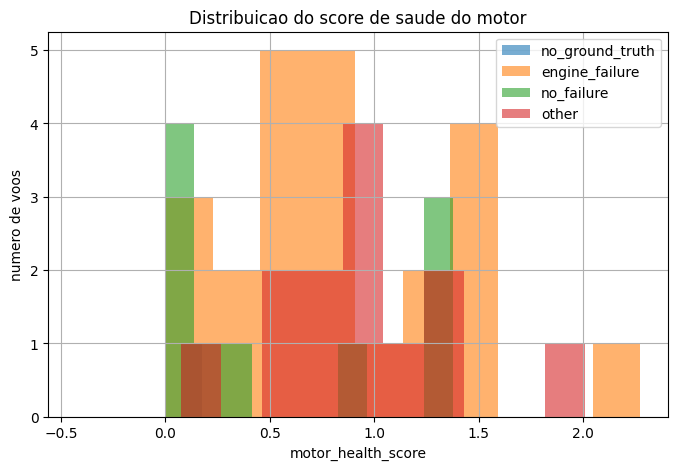

In [14]:
# Gráfico 1 — distribuição do score

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

df = pd.read_csv(DATA_ROOT / "motor_health_score.csv")

df = df[df["status"] == "ok"]

plt.figure(figsize=(8,5))

for t in df["flight_type"].unique():
    subset = df[df["flight_type"] == t]
    plt.hist(subset["motor_health_score"], bins=10, alpha=0.6, label=t)

plt.xlabel("motor_health_score")
plt.ylabel("numero de voos")
plt.title("Distribuicao do score de saude do motor")
plt.legend()
plt.grid(True)
plt.show()

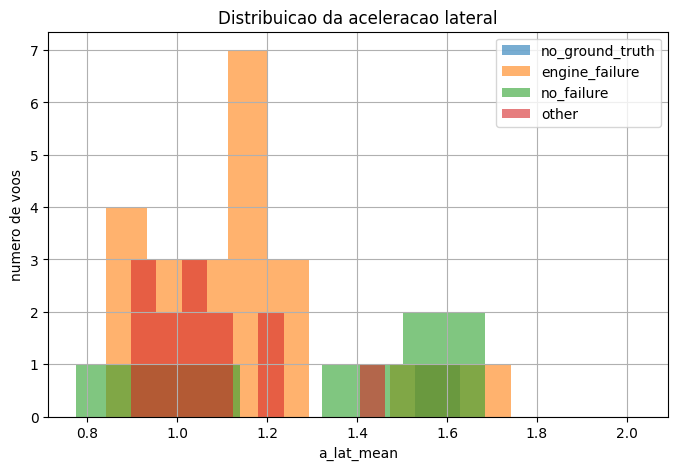

In [15]:
# Gráfico 2 — aceleração lateral

df2 = pd.read_csv(DATA_ROOT / "motor_dynamic_metrics_v2.csv")
df2 = df2[df2["status"] == "ok"]

plt.figure(figsize=(8,5))

for t in df2["flight_type"].unique():
    subset = df2[df2["flight_type"] == t]
    plt.hist(subset["a_lat_mean"], bins=10, alpha=0.6, label=t)

plt.xlabel("a_lat_mean")
plt.ylabel("numero de voos")
plt.title("Distribuicao da aceleracao lateral")
plt.legend()
plt.grid(True)
plt.show()

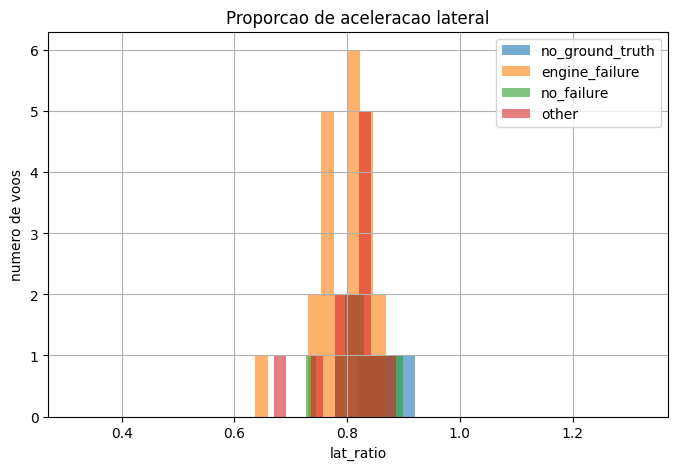

In [16]:
# Gráfico 3 — lat_ratio

plt.figure(figsize=(8,5))

for t in df2["flight_type"].unique():
    subset = df2[df2["flight_type"] == t]
    plt.hist(subset["lat_ratio"], bins=10, alpha=0.6, label=t)

plt.xlabel("lat_ratio")
plt.ylabel("numero de voos")
plt.title("Proporcao de aceleracao lateral")
plt.legend()
plt.grid(True)
plt.show()

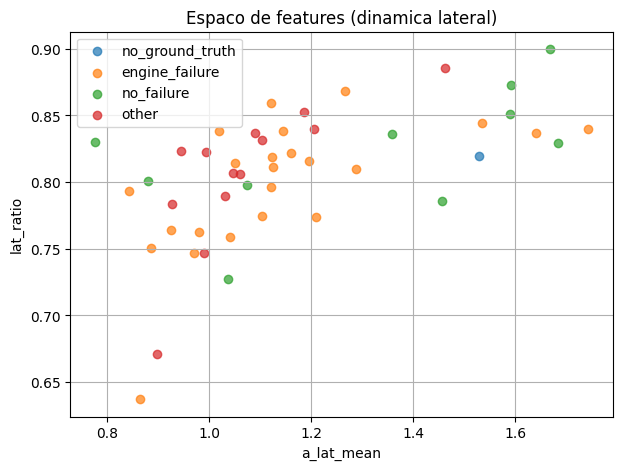

In [17]:
# Gráfico 4 — scatter

plt.figure(figsize=(7,5))

for t in df2["flight_type"].unique():
    subset = df2[df2["flight_type"] == t]
    plt.scatter(subset["a_lat_mean"], subset["lat_ratio"], label=t, alpha=0.7)

plt.xlabel("a_lat_mean")
plt.ylabel("lat_ratio")
plt.title("Espaco de features (dinamica lateral)")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# Treinamento de um modelo de Random Forest para classificar voos como normais ou com falha, as métricas utilizadas são de aceleração e desequilíbrio lateral como indicadores preditivos."

from pathlib import Path
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

df = pd.read_csv(DATA_ROOT / "motor_dynamic_metrics_v2.csv")

# -------------------------
# 1. Mantém somente as classes úteis
# -------------------------
df = df[df["status"] == "ok"]

df = df[df["flight_type"].isin(["engine_failure", "no_failure"])].copy()

# -------------------------
# 2. cria alvo (y)
# -------------------------
df["target"] = df["flight_type"].map({
    "engine_failure": 1,
    "no_failure": 0
})

# -------------------------
# 3. Features (X)
# -------------------------
features = ["a_lat_mean", "a_total_mean", "lat_ratio"]

X = df[features]
y = df["target"]

print("Total de amostras:", len(df))
print("\nContagem por classe:")
print(df["target"].value_counts())

# -------------------------
# 4. Treino e teste
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -------------------------
# 5. Modelo
# -------------------------
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# -------------------------
# 6. Avaliação
# -------------------------
y_pred = model.predict(X_test)

print("\nAcuracia:")
print(accuracy_score(y_test, y_pred))

print("\nRelatorio:")
print(classification_report(y_test, y_pred))

Total de amostras: 33

Contagem por classe:
target
1    23
0    10
Name: count, dtype: int64

Acuracia:
0.7

Relatorio:
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.75      0.86      0.80         7

    accuracy                           0.70        10
   macro avg       0.62      0.60      0.60        10
weighted avg       0.68      0.70      0.68        10



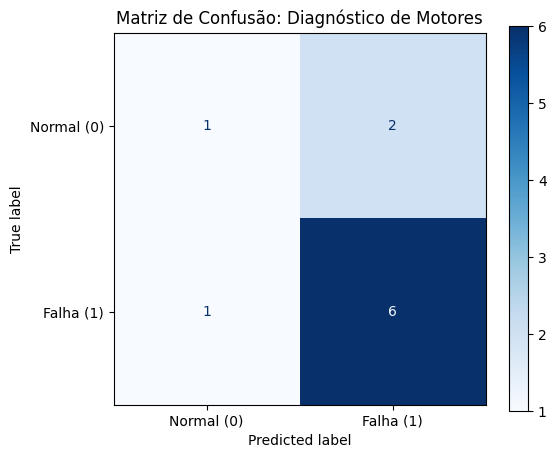

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Gera a matriz numérica
cm = confusion_matrix(y_test, y_pred)

# 2. Configura a visualização
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Falha (1)"])

# 3. Plota o gráfico
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax)
plt.title("Matriz de Confusão: Diagnóstico de Motores")
plt.show()

In [20]:
import pandas as pd

importance = pd.DataFrame({
    "feature": ["a_lat_mean", "a_total_mean", "lat_ratio"],
    "importance": model.feature_importances_
})

importance = importance.sort_values("importance", ascending=False)

print(importance)

        feature  importance
1  a_total_mean    0.344082
0    a_lat_mean    0.339528
2     lat_ratio    0.316390


In [21]:
#Este script utiliza o modelo de Random Forest previamente treinado para realizar a inferência  em voos que não possuem rótulo conhecido (no_ground_truth).

from pathlib import Path
import pandas as pd

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

# carregar features
df_all = pd.read_csv(DATA_ROOT / "motor_dynamic_metrics_v2.csv")

# manter só dados válidos
df_all = df_all[df_all["status"] == "ok"].copy()

# selecionar voos sem rótulo
df_ngt = df_all[df_all["flight_type"] == "no_ground_truth"].copy()

print("Quantidade de voos sem rótulo:", len(df_ngt))

# features usadas no modelo
features = ["a_lat_mean", "a_total_mean", "lat_ratio"]

X_ngt = df_ngt[features]

# prevê
df_ngt["pred"] = model.predict(X_ngt)

# probabilidade (muito importante)
df_ngt["prob_failure"] = model.predict_proba(X_ngt)[:, 1]

# mapea rótulo
df_ngt["pred_label"] = df_ngt["pred"].map({
    0: "normal",
    1: "possivel_falha"
})

print("\nResultados:")
print(df_ngt[[
    "flight",
    "pred_label",
    "prob_failure"
]])

Quantidade de voos sem rótulo: 1

Resultados:
                                        flight pred_label  prob_failure
0  carbonZ_2018-07-18-12-10-11_no_ground_truth     normal          0.29


In [22]:
#  Aqui aplicamos o modelo treinado sobre os voos da categoria other

from pathlib import Path
import pandas as pd

DATA_ROOT = Path("/content/gdrive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")

# carregar dados
df_all = pd.read_csv(DATA_ROOT / "motor_dynamic_metrics_v2.csv")

# manter apenas válidos
df_all = df_all[df_all["status"] == "ok"].copy()

# selecionar voos "other"
df_other = df_all[df_all["flight_type"] == "other"].copy()

print("Quantidade de voos 'other':", len(df_other))

# features usadas no modelo
features = ["a_lat_mean", "a_total_mean", "lat_ratio"]

X_other = df_other[features]

# prever
df_other["pred"] = model.predict(X_other)
df_other["prob_failure"] = model.predict_proba(X_other)[:, 1]

# mapear rótulo
df_other["pred_label"] = df_other["pred"].map({
    0: "normal",
    1: "possivel_falha"
})

# ordenar por risco (muito importante)
df_other = df_other.sort_values("prob_failure", ascending=False)

print("\nRanking de risco:")
print(df_other[[
    "flight",
    "pred_label",
    "prob_failure"
]])

Quantidade de voos 'other': 13

Ranking de risco:
                                               flight      pred_label  \
33  carbonZ_2018-10-05-14-37-22_2_right_aileron_fa...  possivel_falha   
28  carbonZ_2018-09-11-17-55-30_1_right_aileron_fa...  possivel_falha   
21     carbonZ_2018-09-11-15-05-11_1_elevator_failure  possivel_falha   
34  carbonZ_2018-10-05-14-37-22_3_left_aileron_fai...  possivel_falha   
31  carbonZ_2018-10-05-14-34-20_2_right_aileron_fa...  possivel_falha   
20  carbonZ_2018-09-11-14-52-54_left_aileron__righ...  possivel_falha   
19       carbonZ_2018-09-11-14-41-51_elevator_failure  possivel_falha   
26  carbonZ_2018-09-11-17-27-13_1_rudder_zero__lef...  possivel_falha   
24  carbonZ_2018-09-11-15-06-34_2_rudder_right_fai...  possivel_falha   
27  carbonZ_2018-09-11-17-27-13_2_both_ailerons_fa...  possivel_falha   
23  carbonZ_2018-09-11-15-06-34_1_rudder_right_fai...  possivel_falha   
25  carbonZ_2018-09-11-15-06-34_3_rudder_left_failure          normal   
2